<a href="https://colab.research.google.com/github/joaoalexandre14/ex_8avcad/blob/main/ex8avcad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the data (replace with the exact extracted filename)
df = pd.read_csv('EFIplus_medit.csv', sep=';')

# Log-transform highly skewed variables to linearize the relationship
df['Actual_river_slope'] = np.log1p(df['Actual_river_slope'])
df['Altitude'] = np.log1p(df['Altitude'])
df['Elevation_mean_catch'] = np.log1p(df['Elevation_mean_catch'])

# Continuous variables and target variable
target = 'Total_sp' # Replace with the exact column name if different
predictors = ['Altitude', 'Actual_river_slope', 'Elevation_mean_catch',
              'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul']

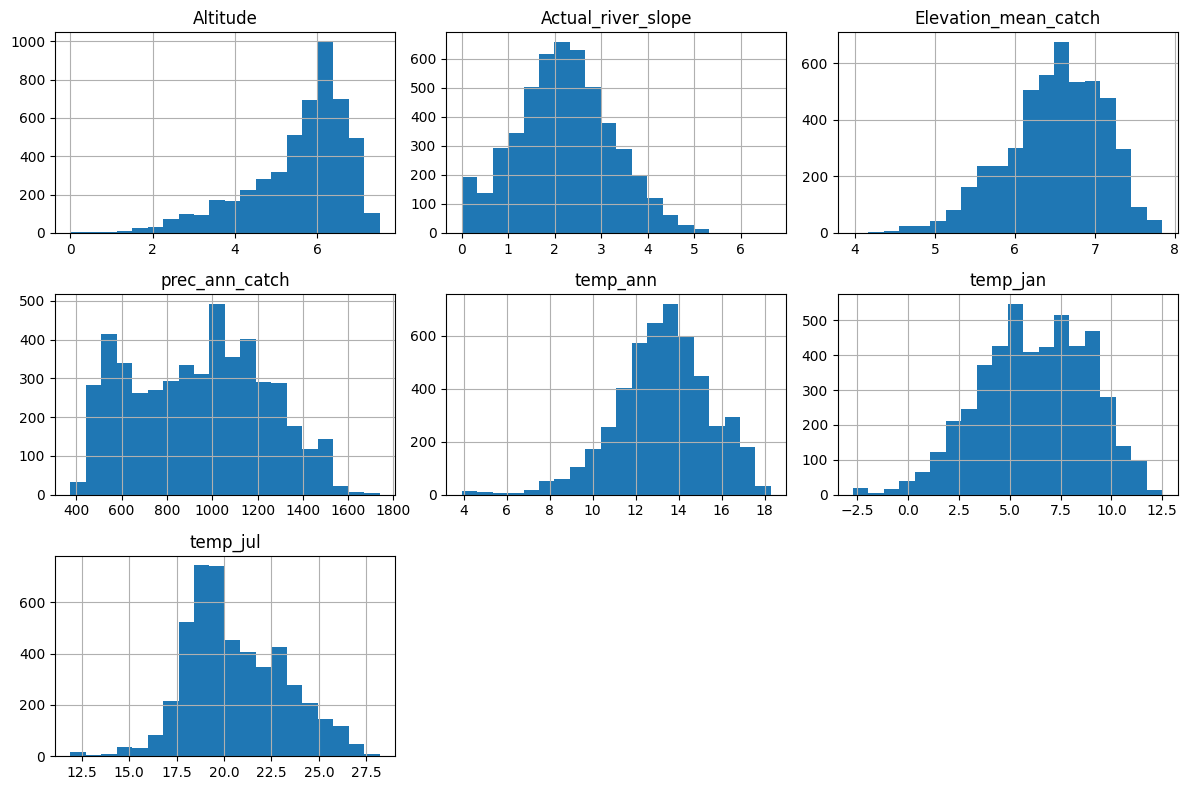

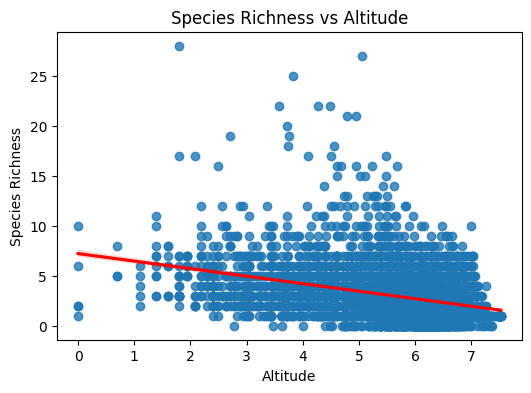

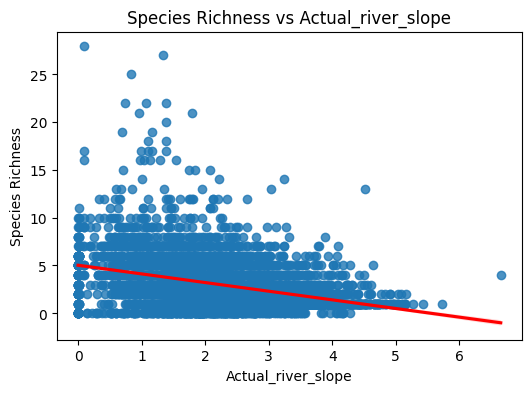

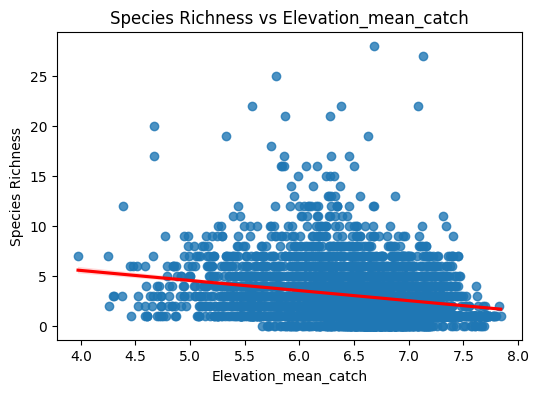

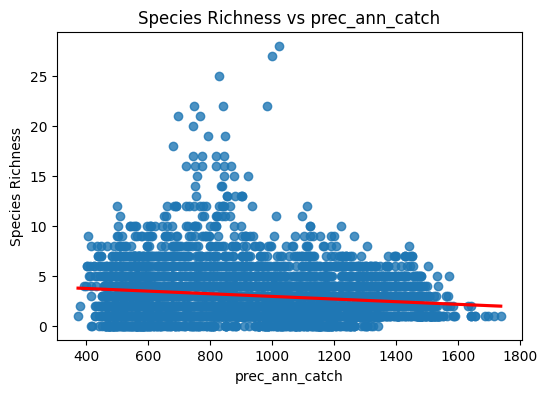

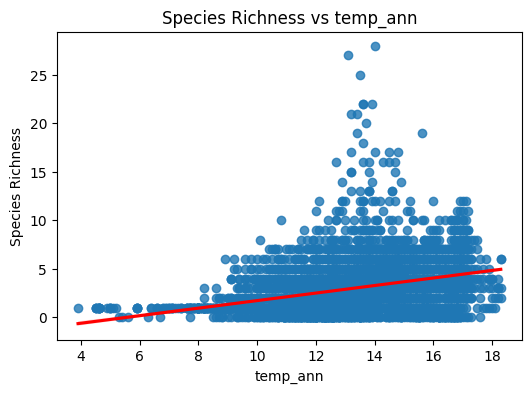

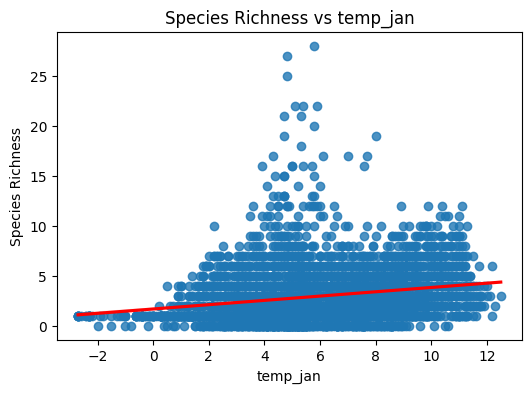

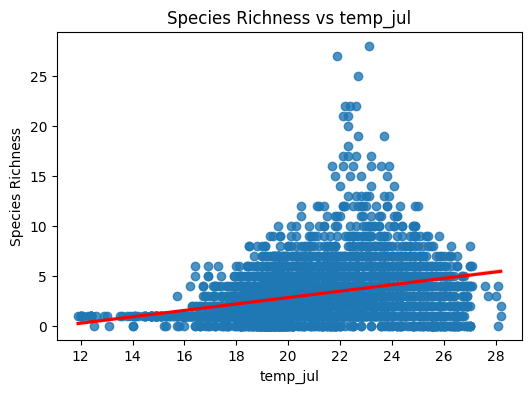

--- Univariate Regression Results ---
                      Coefficient  R-squared  F-statistic
Altitude                -0.752051   0.129340   744.106274
Actual_river_slope      -0.904492   0.132502   759.576136
Elevation_mean_catch    -1.007497   0.058574   301.074737
prec_ann_catch          -0.001319   0.023167   114.763154
temp_ann                 0.388504   0.110822   603.103686
temp_jan                 0.215228   0.051087   260.517520
temp_jul                 0.320188   0.106434   576.382907


In [20]:
# Check variable distributions to evaluate the need for transformations
df[predictors].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

# You can apply transformations here if needed, e.g., np.log1p(df['Actual_river_slope'])

univariate_results = {}

for var in predictors:
    # Define X and y
    X_raw = df[[var]]
    y_raw = df[target]

    # Combine X and y into a temporary DataFrame to handle NaNs/Infs consistently
    temp_df = pd.concat([y_raw, X_raw], axis=1)

    # Replace inf/-inf with NaN and then drop rows with NaNs
    temp_df = temp_df.replace([np.inf, -np.inf], np.nan).dropna()

    # Re-assign y and X from the cleaned temporary DataFrame
    y_cleaned = temp_df[target]
    X_cleaned = sm.add_constant(temp_df[[var]]) # Add constant after cleaning

    # Fit the OLS model
    model = sm.OLS(y_cleaned, X_cleaned).fit()

    # Store the results
    univariate_results[var] = {
        'Coefficient': model.params[var],
        'R-squared': model.rsquared,
        'F-statistic': model.fvalue
    }

    # Optional: Plot the fitted model
    plt.figure(figsize=(6, 4))
    sns.regplot(x=temp_df[var], y=y_cleaned, line_kws={"color": "red"})
    plt.title(f'Species Richness vs {var}')
    plt.xlabel(var)
    plt.ylabel('Species Richness')
    plt.show()

# Display the results cleanly
df_uni_results = pd.DataFrame(univariate_results).T
print("--- Univariate Regression Results ---")
print(df_uni_results)


--- Multiple Regression Model ---
                            OLS Regression Results                            
Dep. Variable:               Total_sp   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     166.8
Date:                Thu, 21 May 2026   Prob (F-statistic):          1.64e-221
Time:                        18:53:02   Log-Likelihood:                -10802.
No. Observations:                4819   AIC:                         2.162e+04
Df Residuals:                    4811   BIC:                         2.167e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------

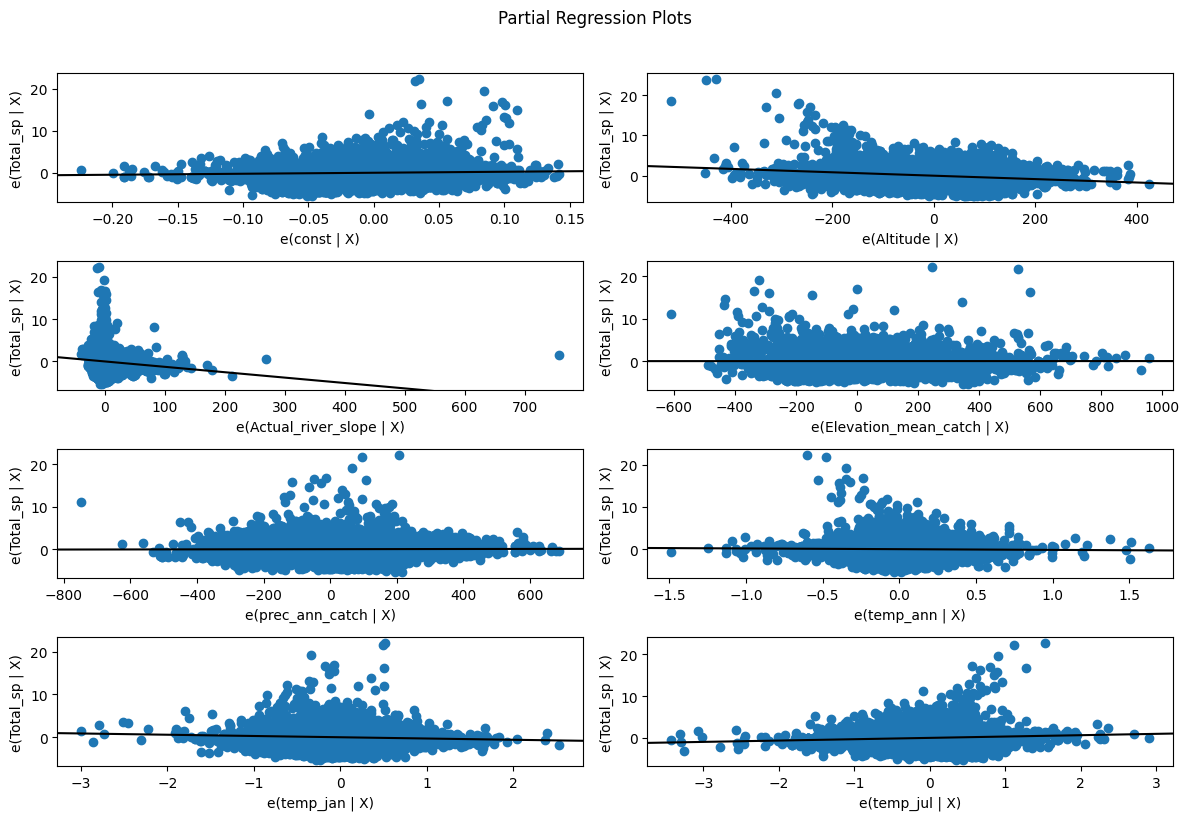

In [15]:
# Define X with all predictors and add constant
X_multi_raw = df[predictors]
y_raw = df[target]

# Combine X and y into a temporary DataFrame to handle NaNs/Infs consistently
temp_df_multi = pd.concat([y_raw, X_multi_raw], axis=1)

# Replace inf/-inf with NaN and then drop rows with NaNs
temp_df_multi = temp_df_multi.replace([np.inf, -np.inf], np.nan).dropna()

# Re-assign y and X_multi from the cleaned temporary DataFrame
y_cleaned = temp_df_multi[target]
X_multi_cleaned = sm.add_constant(temp_df_multi[predictors])

# Fit the multiple regression model
multi_model = sm.OLS(y_cleaned, X_multi_cleaned).fit()
print("\n--- Multiple Regression Model ---")
print(multi_model.summary())

# Partial Regression Plots to compare responses with previous single effects
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_partregress_grid(multi_model, fig=fig)
plt.suptitle('Partial Regression Plots', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Calculate Variance Inflation Factor (VIF) to check for multicollinearity
vif_data = pd.DataFrame()
vif_data["Variable"] = X_multi_cleaned.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi_cleaned.values, i) for i in range(X_multi_cleaned.shape[1])]

print("\n--- Variance Inflation Factors (VIF) ---")
print(vif_data)

# Replace this list with the variables that "survived" the VIF test (usually VIF < 5)
# Example assuming these are the ones kept:
parsimonious_predictors = ['Altitude', 'Actual_river_slope', 'prec_ann_catch', 'temp_ann']

# Define X with the parsimonious predictors and add constant
# Ensure X_final is also cleaned
X_final_raw = temp_df_multi[parsimonious_predictors]

# The target y_cleaned is already clean from the previous step
X_final = sm.add_constant(X_final_raw)

# Fit the second, more parsimonious model
final_model = sm.OLS(y_cleaned, X_final).fit()

# Check how the coefficients have changed
print("\n--- Parsimonious Regression Model ---")
print(final_model.summary())


--- Variance Inflation Factors (VIF) ---
               Variable         VIF
0                 const  438.217931
1              Altitude    8.399756
2    Actual_river_slope    1.132702
3  Elevation_mean_catch    5.234322
4        prec_ann_catch    2.451558
5              temp_ann   73.560766
6              temp_jan   28.851849
7              temp_jul   21.222423

--- Parsimonious Regression Model ---
                            OLS Regression Results                            
Dep. Variable:               Total_sp   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     214.1
Date:                Thu, 21 May 2026   Prob (F-statistic):          2.72e-169
Time:                        18:54:16   Log-Likelihood:                -10931.
No. Observations:                4819   AIC:                         2.187e+04
Df Residuals:                    4814   BI

### Final Regression Analysis Conclusions

#### 1. Univariate vs. Multiple Regression (Coefficient Shifts)
When transitioning from simple linear regression models to the multiple regression model, a significant change in the magnitude and sometimes the sign of the coefficients associated with the predictor variables was observed.

For instance, the variable `Altitude` presented a coefficient of `-0.752` in the univariate model, indicating a strong isolated negative effect. However, in the multiple model, this coefficient changed to `-0.0042`. This variation occurs because, in the multiple regression, the effect of each variable is estimated while holding the remaining variables constant (*ceteris paribus*). The variance that was previously attributed solely to one variable is now shared with other correlated environmental predictors.

#### 2. Partial Dependence Plots Analysis
The partial regression plots confirm the dynamics of the multiple model. While the initial univariate models showed the gross correlation between Species Richness and each variable, the partial plots and multiple regression coefficients reveal the marginal effect of each predictor after removing the influence of the remaining variables in the model.

A clear example of this is `temp_jan`. In the simple regression, it showed a positive relationship with Species Richness (coefficient of `0.215`). However, in the multiple regression model, its coefficient reverses completely to `-0.295`. This indicates that its apparent initial positive effect was actually driven by other highly correlated variables (confounding effect), and its actual independent impact on species richness is completely different. Conversely, variables like `Altitude` and `Actual_river_slope` maintained a clear negative impact in both simple and multiple models, proving their robust independent effect regardless of other conditions.

#### 3. Multicollinearity and Parsimonious Model Selection
The Variance Inflation Factor (VIF) analysis revealed the presence of severe multicollinearity in the full multiple model, as corroborated by the model's high condition number. As expected in ecological and topographical data, temperature variables (`temp_ann` VIF = 73.5, `temp_jan` VIF = 28.8, `temp_jul` VIF = 21.2) and altimetry variables (`Altitude` VIF = 8.4, `Elevation_mean_catch` VIF = 5.2) exhibited extremely high VIF values, indicating severe information redundancy.

To build a parsimonious and statistically stable model, highly collinear variables were removed, retaining the following predictors: `Altitude`, `Actual_river_slope`, `prec_ann_catch`, and `temp_ann`.

**Final Comparison:**
In the parsimonious model, the standard errors of the estimates stabilized compared to the initial multiple model, and the critical multicollinearity was addressed. Although the R-squared value suffered a slight decrease from `0.195` (Multiple model) to `0.151` (Parsimonious model), this simplified model is more robust, interpretably stable, and less prone to overfitting, making it a more reliable representation of the environmental drivers of Species Richness in the EFIplus dataset.